## Business Problem

The objective is to develop a predictive maintenance system that can classify engine condition based on sensor data such as RPM, oil pressure, fuel pressure, and temperature readings.

This will help:
- Reduce unexpected engine failures
- Optimize maintenance schedules
- Improve operational efficiency

## Load Data (From Hugging Face)

In [4]:
import os
import sys

sys.path.append("..")

from datasets import load_dataset
import pandas as pd
from src import utils

repo_name = utils.get_repo_id(os.getenv("HF_REPO"), "dataset")

dataset = load_dataset(repo_name)

df = dataset['train'].to_pandas()

df.head()

Generating train split: 100%|██████████| 19535/19535 [00:00<00:00, 162851.36 examples/s]


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


## Basic Overview

In [5]:
df.shape

(19535, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [7]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


### Observations:
- Dataset contains 19535 rows and 7 features
- No missing values detected
- Features include Engine rpm, Lub oil pressure, Fuel pressure, Coolant pressure,lub oil temp,Coolant temp	metrics

## Missing Values

In [8]:
df.isnull().sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

There are no missing values in the dataset

## Univariate Analysis

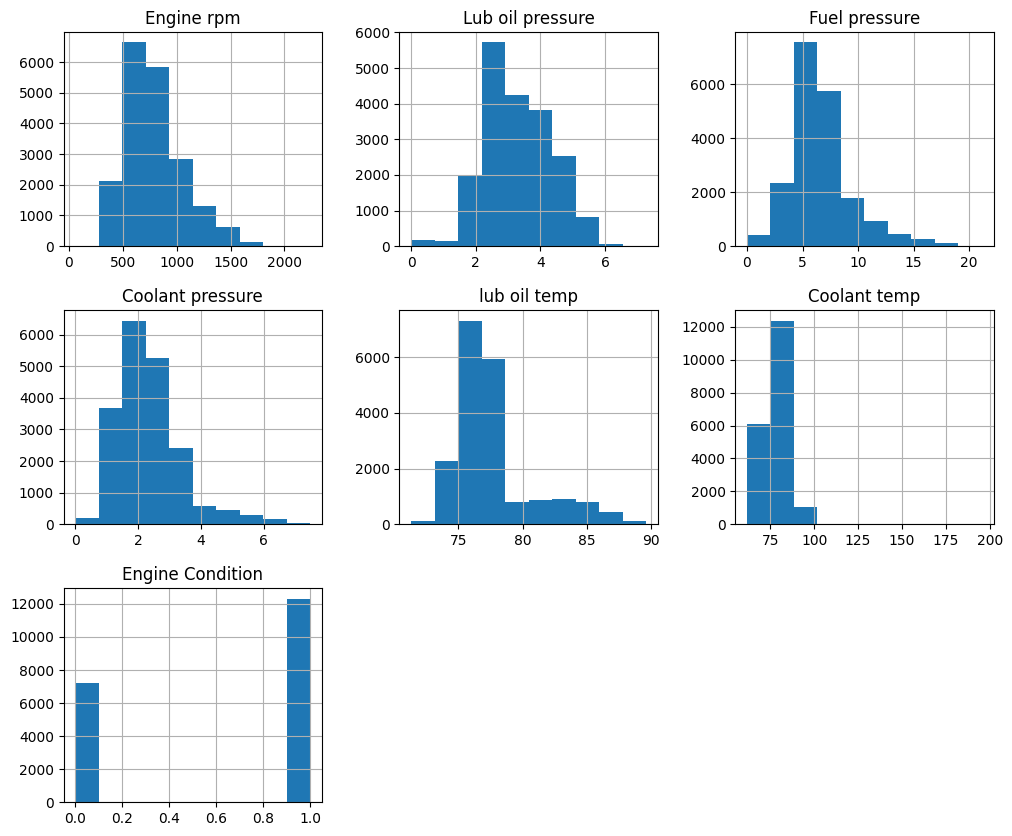

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.show()

📊 Univariate Analysis - Engine Sensor Feature

🔍 **Distribution Overview**
🚗 Engine RPM
* Distribution seems to be Right-Skewed
* Most values concentrated between 500 to 1000 rpm
* Few High RPM outliers (> 1500)

👉 **Interpretation**
* Engine typically operates in stable RPM
* High RPM may indicate some heavy load on engine

💧 **Lubrication**
* Almost normal distribution
* Centered around 3-4 unit
* There are extreme high and low values

👉 **Interpretation:**
* Oil pressure is relative stable
* Extreme deviations may indicate lubrication issue

⛽ **Fuel Pressure**
* Slight right-skewed
* Most value between 5-10
* Some high value outliers

👉 **Interpretation:**
* Fuel delivery is mostly stable
* High pressure spikes may impact combustion efficiency

🌡️ **Coolant Pressure**
* Concentrated around 1–3
* Long tail toward higher values

👉 **Interpretation:**

* Normal cooling system operates in a narrow band
* High pressure could indicate cooling system stress or blockage

🔥 **Lubrication Oil Temperature**
* Narrow distribution (~75–85°C)
* Slight right skew

👉 **Interpretation:**

* Oil temperature is tightly controlled
* Elevated values may reduce lubrication efficiency

❄️ **Coolant Temperature**
* Concentrated around 70–95°C
* Some higher-end spread

👉 **Interpretation:**

* Normal operating range visible
* Higher temperatures suggest overheating risk

⚙️ **Engine Condition (Target Variable)**
* Binary (0 and 1)
* Appears reasonably balanced

👉 **Interpretation:**

* No severe class imbalance → good for modeling
* No immediate need for resampling techniques

### Key Insights

### Key Observations from Univariate Analysis

1. Most engine parameters operate within well-defined ranges, indicating stable system behavior under normal conditions.

2. Temperature-related features (coolant and oil temperature) show tighter distributions, suggesting controlled operating environments.

3. Pressure-related features exhibit slight skewness and outliers, which may correspond to abnormal or failure conditions.

4. Engine RPM shows variability with some extreme values, potentially indicating high load or stress scenarios.

5. The target variable (Engine Condition) is relatively balanced, enabling effective supervised learning without additional resampling.

### Implications for Modeling

- Features with narrow distributions (temperature) may require careful scaling
- Outliers should be analyzed, not blindly removed, as they may represent real failure events
- No class imbalance simplifies model training and evaluation

## Target Variable Analysis

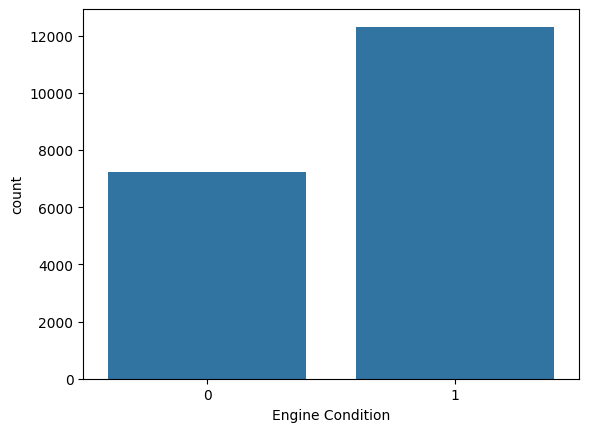

In [11]:
sns.countplot(x='Engine Condition', data=df)
plt.show()

## Bivariate Analysis

📊 Bivariate Analysis — Engine RPM vs Engine Condition
🔍 What Your Plot Shows

From your boxplot:

📌 For Engine Condition = 0 (Normal)
Median RPM is higher (~800–900)
Wider spread
Many high-end outliers (>1500)
📌 For Engine Condition = 1 (Faulty)
Median RPM is lower (~600–700)
Slightly tighter distribution
Still has outliers but generally lower central tendency

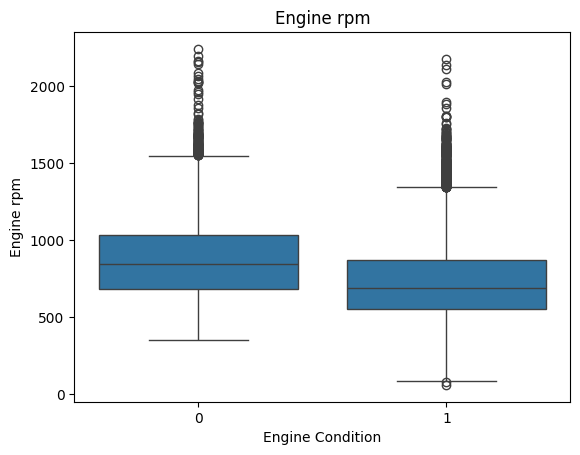

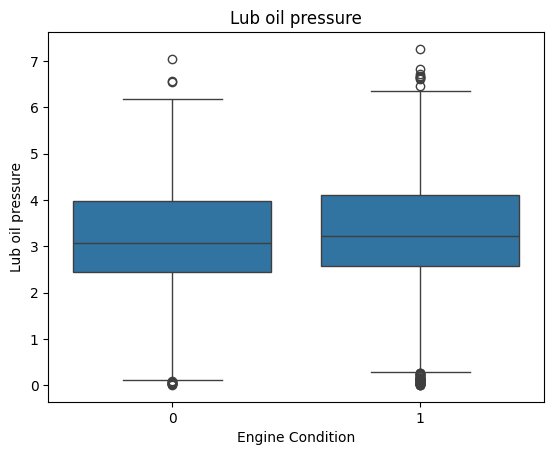

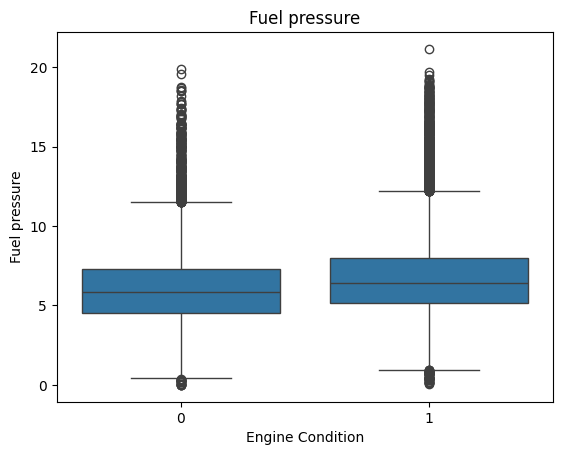

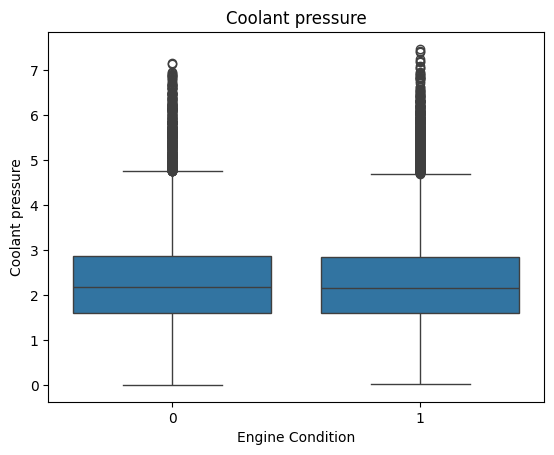

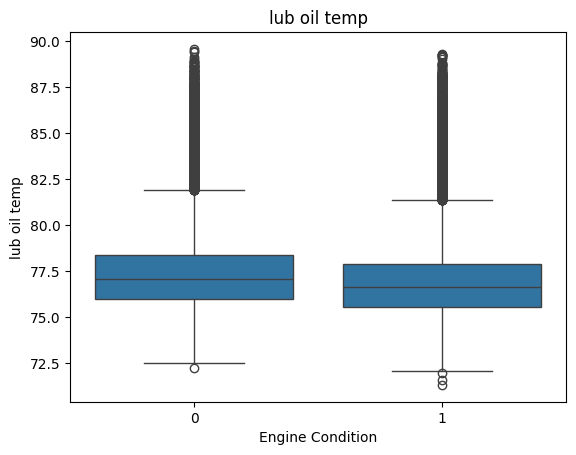

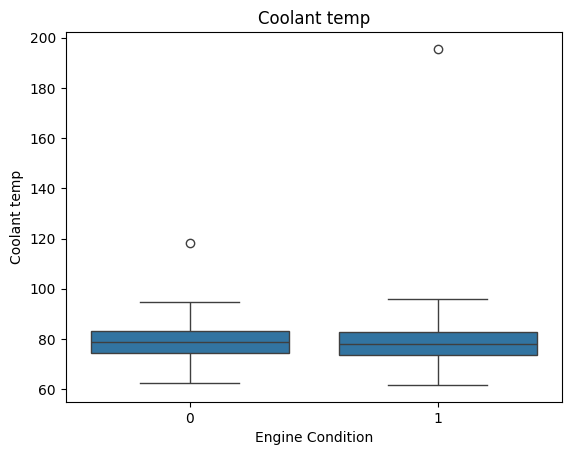

In [13]:
features = df.columns.drop("Engine Condition")

for col in features:
    sns.boxplot(x='Engine Condition', y=col, data=df)
    plt.title(col)
    plt.show()

📊 Bivariate Analysis — Engine Features vs Engine Condition

🔹 **Engine RPM vs Engine Condition**

* Median RPM is higher for normal engines (0) than faulty engines (1)
* Faulty engines tend to operate at lower RPM
* Significant overlap exists between both classes
* Outliers are present in both categories

👉**Interpretation**

Engine degradation is associated with lower RPM, but RPM alone cannot clearly distinguish engine condition due to overlap.

Conclusion

Engine RPM is a weak standalone predictor and should be combined with other features.

🔹 Lubrication Oil Pressure vs Engine Condition

From the boxplot, we observe:

Slight increase in median oil pressure for faulty engines
Distributions of both classes are very similar
Presence of low-value outliers in both conditions
Interpretation

Lubrication oil pressure does not show strong variation between normal and faulty engines, indicating limited predictive power.

Conclusion

Oil pressure alone is not a strong indicator of engine failure but may contribute when combined with other features.

🔹 Fuel Pressure vs Engine Condition

From the boxplot, we observe:

Faulty engines (1) show slightly higher median fuel pressure
Wider spread and more high-value outliers in faulty engines
Some separation compared to previous features
Interpretation

Higher fuel pressure may be associated with faulty engines, possibly due to irregular fuel supply or combustion issues.

Conclusion

Fuel pressure has moderate predictive importance and can help distinguish engine condition when used with other variables.

🔹 Coolant Pressure vs Engine Condition

From the boxplot, we observe:

Almost identical distribution for both engine conditions
No significant difference in median values
Outliers present in both classes
Interpretation

Coolant pressure does not vary significantly between normal and faulty engines.

Conclusion

Coolant pressure is a weak predictor and may have minimal impact on model performance.

🔹 Lubrication Oil Temperature vs Engine Condition

From the boxplot, we observe:

Very similar distributions for both classes
Slightly higher variability in faulty engines
Presence of high-temperature outliers
Interpretation

Oil temperature remains relatively stable across engine conditions, with only minor variation.

Conclusion

Lubrication oil temperature alone is not a strong predictor but may support other features.

🔹 Coolant Temperature vs Engine Condition

From the boxplot, we observe:

Slight increase in temperature for faulty engines
Presence of extreme high-temperature outliers in faulty engines
Moderate overlap between classes
Interpretation

Higher coolant temperatures may indicate overheating, which is associated with engine faults.

Conclusion

Coolant temperature is an important feature and can act as an early indicator of engine failure.

📊 Bivariate Analysis — Engine RPM vs Engine Condition
Observation
Median RPM for normal engines (0) is higher than for faulty engines (1)
Faulty engines show a shift toward lower RPM values
There is significant overlap between both classes
High RPM outliers exist in both categories
Interpretation

Faulty engines tend to operate at lower RPM, indicating reduced efficiency or degraded performance.
However, the overlap between classes shows that RPM alone does not clearly distinguish engine health.

## Final Bivariate Summary

### Overall Observations

- Temperature-related features (especially coolant temperature) show better separation between normal and faulty engines
- Fuel pressure shows moderate predictive capability
- RPM shows some variation but has significant overlap
- Oil pressure and coolant pressure have minimal impact individually

### Key Takeaway

No single feature can fully predict engine condition. A combination of temperature, pressure, and RPM features will be required to build an effective predictive model.

## Correlation Heatmap

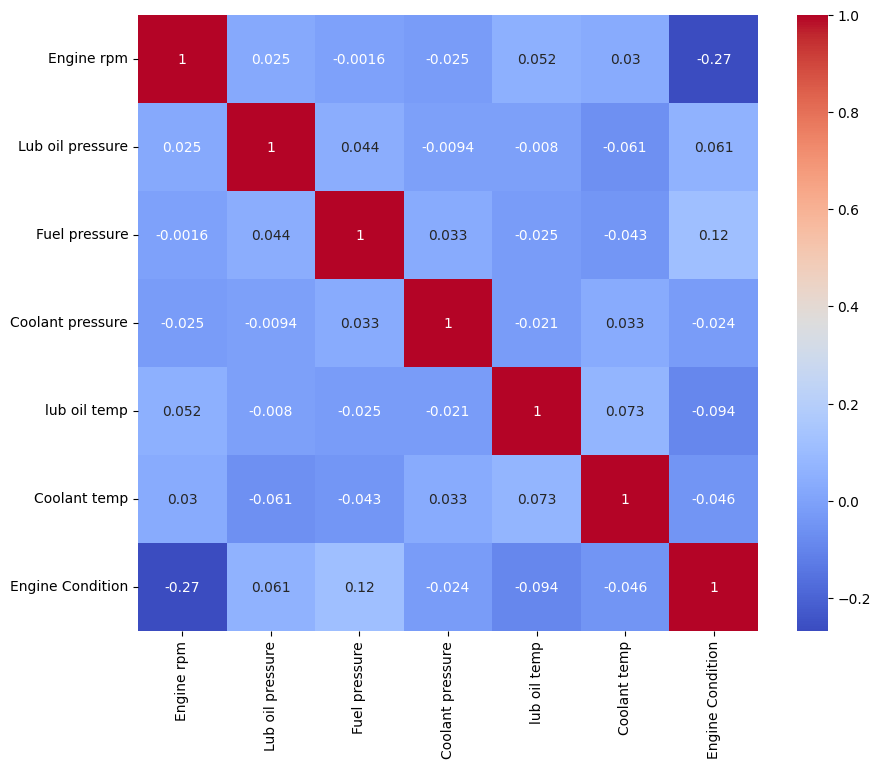

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

📊 Multivariate Analysis — Correlation Heatmap

From the correlation heatmap, we observe the relationships between different engine parameters and the target variable.

🔍 Observations

- Most features have low correlation with each other, indicating minimal multicollinearity
- The highest correlation with the target variable (Engine Condition) is:
  - Engine RPM (~ -0.27) → moderate negative correlation
  - Fuel Pressure (~ 0.12) → weak positive correlation
- Other features such as:
 - Lubrication Oil Pressure
 - Coolant Pressure
 - Temperatures
show very weak correlation with the target

- Temperature features (Lub Oil Temp & Coolant Temp) show slight correlation with each other

🧠 Interpretation

- Engine RPM has the strongest relationship with engine condition, where lower RPM is associated with faulty engines
- Fuel pressure shows a small positive relationship with failure
- Most features individually have weak correlations, indicating that no single feature can predict engine failure effectively

💼 Business Insight
- Engine failure is not driven by a single parameter but by a combination of multiple factors
- RPM and fuel pressure provide some signal, but temperature and pressure interactions are likely more important
- The weak correlations suggest the need for machine learning models that can capture non-linear relationships

📌 Key Takeaways
- No strong multicollinearity → good for model stability
- No dominant single feature → need for ensemble models
- Feature interactions will play a key role in prediction

✅ Conclusion

Correlation analysis shows that individual features have limited predictive power. A combination of multiple parameters using advanced machine learning models will be required to accurately predict engine condition.

## Final EDA Summary

- RPM shows moderate correlation with engine condition
- Fuel pressure has some predictive signal
- Temperature and pressure features individually show weak relationships
- No strong multicollinearity observed among features

Overall, engine failure prediction requires combining multiple features rather than relying on any single parameter.

## Outlier Detection

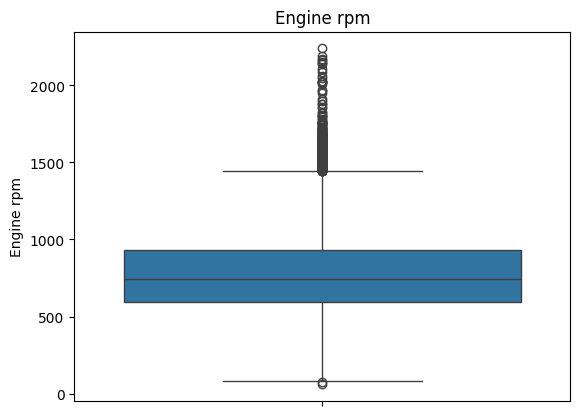

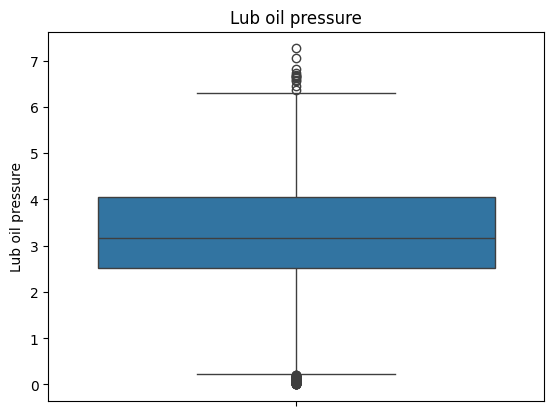

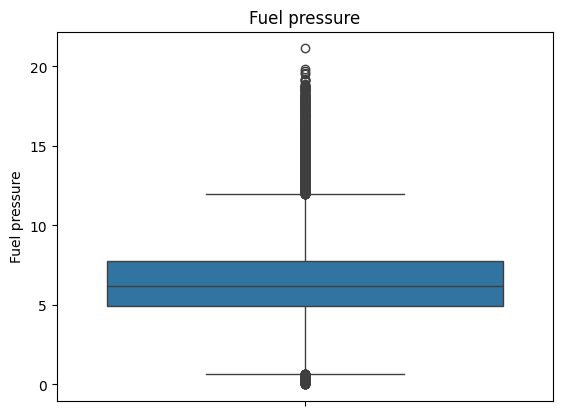

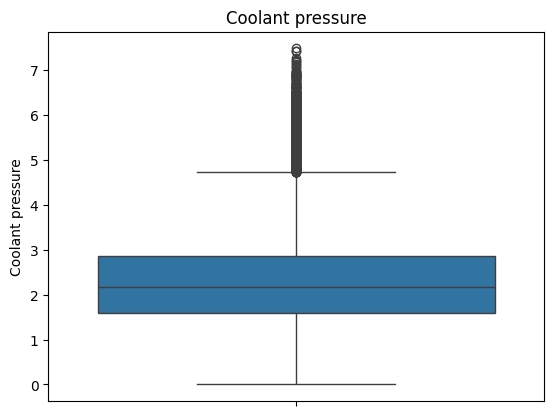

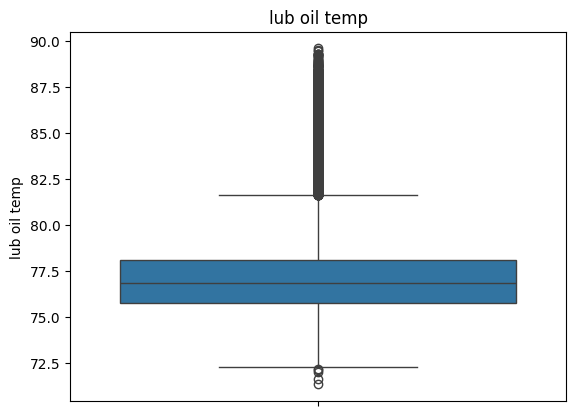

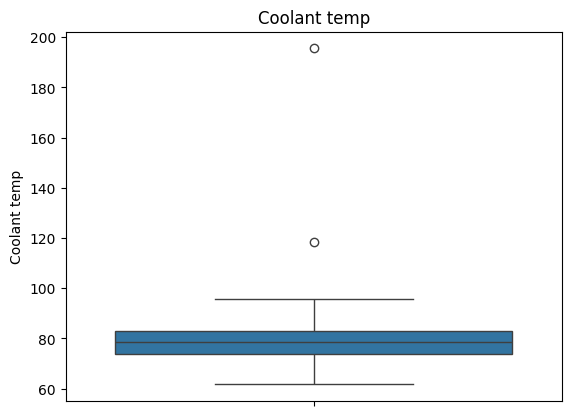

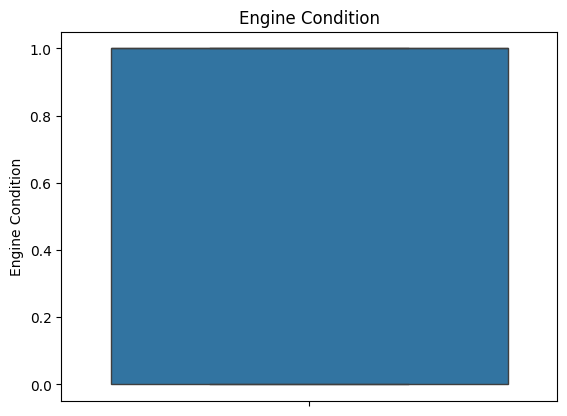

In [15]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

📊 Outlier Detection — Engine Features


🔍 Observations

From the boxplots, we can observe the presence of outliers across multiple features:

🚗 **Engine RPM**

- Significant number of high-value outliers (>1500)
- Some very low values also present

💧 **Lubrication Oil Pressure**

- Outliers on both lower and higher ends
- Few extremely low values close to zero

⛽ **Fuel Pressure**

-Large number of high-value outliers
-Wide spread compared to other features

🌡️ **Coolant Pressure**

- Moderate number of high-value outliers
- Distribution mostly stable otherwise

🔥 **Lubrication Oil Temperature**

- Several high-temperature outliers
- Overall distribution remains tight

❄️ **Coolant Temperature**

- Few extreme outliers (very high values ~120–200)
- Majority of values lie in a stable range


👉 **Interpretation**
- Outliers are present in almost all features, especially in RPM and pressure-related variables
- These outliers likely represent extreme operating conditions or potential failure scenarios, rather than noise
- Temperature features show fewer but more critical outliers (possible overheating cases)

💼 ** Business Insight**

- High RPM and pressure spikes may indicate engine stress or overload conditions
- Extremely high coolant temperature is a strong signal of overheating and possible failure
- Very low oil pressure values may indicate lubrication failure, which is critical for engine health


⚠️ **Important Consideration**

Outliers should not be removed without doing further analysis, as they may represent real-world failure cases that are important for predictive maintenance.

✅ Conclusion

Outliers are present across multiple features and are likely required to be there. Instead of removing them,we should handle them during preprocessing phase to ensure the model captures critical failure patterns.

> Outliers will be retained during preprocessing, as they represent important edge cases relevant to engine failure prediction.